# 📊 MODUL PRAKTIKUM VISUALISASI DATA
## Pertemuan 5: Visualisasi Dasar dengan Matplotlib

---
### 👤 A. Identitas Mahasiswa
| Informasi | Keterangan |
| :--- | :--- |
| **Nama Mahasiswa** | **Gathan Hilabi** |
| **NIM** | **60324059** |
| **Program Studi / Kelas** | **Informatika (Kelas A)** |
| **Fakultas / Universitas** | **Fakultas Sains dan Teknologi, UIN K.H. Abdurrahman Wahid Pekalongan** |
| **Mata Kuliah** | **Visualisasi Data** |
| **Pertemuan Ke-** | **5 (Lima)** |
| **Topik Praktikum** | **Visualisasi Dasar dengan Matplotlib (Line Chart, Bar Chart, Scatter Plot, Menyimpan Grafik)** |
| **Bentuk Penilaian** | **Tugas Praktikum 4 (Bobot 3% dari Komponen Tugas & Praktikum)** |
| **Tanggal Praktikum** | **3 Oktober 2026** |

---
### 🎯 B. Capaian Pembelajaran Praktikum (Sub-CPMK)
- **Sub-CPMK:** Mahasiswa mampu membuat grafik dasar (*line chart*, *bar chart*, *scatter plot*) menggunakan pustaka **Matplotlib**.
- **Indikator Keberhasilan:**
  1. Memahami anatomi plot Matplotlib (*Figure*, *Axes*, *Axis*, *Title*, *Label*, *Ticks*, *Grid*).
  2. Mengimplementasikan gaya penulisan kode berorientasi objek (*Object-Oriented style*: `fig, ax = plt.subplots()`).
  3. Memuat, mengeksplorasi, dan membersihkan missing value pada dataset **Auto MPG**.
  4. Mampu memilih dan membuat jenis grafik yang tepat sesuai pertanyaan analitik yang ingin dijawab.
  5. Menyimpan visualisasi ke file gambar beresolusi tinggi dengan kaidah teknis yang benar.
  6. Menerapkan etika dan praktik baik visualisasi data agar grafik informatif, proporsional, dan tidak menyesatkan.

---
### 📚 C. Dasar Teori Singkat
1. **Pengenalan Matplotlib:**  
   Matplotlib adalah pustaka fundamental Python untuk komputasi grafis dan visualisasi statis dua dimensi, dikembangkan sejak tahun 2003 oleh John D. Hunter. Matplotlib merupakan pondasi utama di balik pustaka visualisasi tingkat lanjut seperti Seaborn dan fungsi `plot()` bawaan Pandas DataFrame.
2. **Anatomi Plot Matplotlib:**  
   - **Figure:** Kanvas utama pembungkus seluruh visualisasi.
   - **Axes:** Area koordinat di mana data digambar. Sebuah Figure dapat menampung satu atau banyak Axes (*subplot*).
   - **Axis, Ticks & Grid:** Penentu skala koordinat nilai dan garis pandu pembacaan data.
   - **Title & Labels:** Elemen naratif untuk memberikan konteks, nama variabel, dan satuan ukuran.
3. **Dua Paradigma Penulisan Kode:**  
   - **Gaya Pyplot (Stateful):** Bergantung pada state global mesin grafis (*current figure/axes*). Ringkas namun sulit dikontrol pada grafik multi-panel.
   - **Gaya Berorientasi Objek (Object-Oriented Style):** Secara eksplisit memegang dan memanipulasi objek Figure dan Axes. Merupakan gaya standar yang direkomendasikan dokumentasi resmi Matplotlib dan digunakan penuh pada praktikum ini.
4. **Prinsip Integritas Visual:**  
   Visualisasi data harus jujur (*truthful*). Bar chart wajib bertumpu pada garis dasar nol (*zero baseline*), scatter plot memerlukan penanganan transparansi (*alpha*) saat data padat, dan korelasi statistik harus dipisahkan secara tegas dari klaim sebab-akibat (*correlation ≠ causation*).

---
## 🛠️ E. 10 Langkah-Langkah Praktikum

Pada bagian ini, kita akan menyelesaikan 10 langkah terstruktur sesuai materi Pertemuan 5:
1. Menyiapkan notebook & mengimpor library
2. Mengenal komponen anatomi plot
3. Memahami dua gaya penulisan kode Matplotlib
4. Menyiapkan dataset Auto MPG & pembersihan data kosong
5. Mengeksplorasi struktur dan variabel dataset
6. Membuat Line Chart untuk analisis tren waktu ke waktu
7. Membuat Bar Chart vertikal untuk komparasi kategori
8. Membuat Bar Chart horizontal untuk distribusi frekuensi
9. Membuat Scatter Plot dan analisis korelasi numerik
10. Menyimpan grafik ke file gambar dengan kaidah teknis yang tepat

### 1. Menyiapkan Notebook dan Mengimpor Library
Pada langkah pertama ini, kita mengimpor tiga pustaka fundamental dalam ekosistem sains data Python:
- `matplotlib.pyplot` dengan alias konvensi `plt`: Modul utama pengatur tata letak dan fungsi render grafis.
- `pandas` dengan alias konvensi `pd`: Modul pengolahan data tabular (DataFrame).
- `numpy` dengan alias konvensi `np`: Modul operasi numerik dan array multidimensi.

Kita juga mengonfigurasi pengaturan font dan visualisasi awal agar grafik tampil rapi dan konsisten.

In [1]:
# Langkah 1: Impor Library Utama dan Verifikasi Lingkungan
import os
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Konfigurasi parameter visualisasi global Matplotlib
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.autolayout'] = False

print("=" * 65)
print("     VERIFIKASI LINGKUNGAN PENGEMBANGAN PYTHON & LIBRARY")
print("=" * 65)
print(f"Versi Matplotlib : {matplotlib.__version__}")
print(f"Versi Pandas     : {pd.__version__}")
print(f"Versi NumPy      : {np.__version__}")
print("Status           : Modul berhasil diimpor dan siap digunakan.")
print("=" * 65)

     VERIFIKASI LINGKUNGAN PENGEMBANGAN PYTHON & LIBRARY
Versi Matplotlib : 3.10.6
Versi Pandas     : 2.2.3
Versi NumPy      : 2.1.3
Status           : Modul berhasil diimpor dan siap digunakan.


### 2. Mengenal Anatomi Plot Matplotlib
Matplotlib membagi struktur visualisasi menjadi hierarki komponen:
1. **Figure (`fig`):** Kanvas menyeluruh yang menampung semua elemen grafis (seperti bingkai lukisan).
2. **Axes (`ax`):** Area bidang koordinat 2D tempat data aktual digambar (bidang grafik).
3. **Title & Axis Labels:** Judul grafik serta label penjelas sumbu X dan Y beserta satuannya.
4. **Ticks & Tick Labels:** Garis penanda skala nilai dan label teks penunjuk angka pada sumbu.
5. **Grid:** Garis kisi-kisi bantu untuk memudahkan mata membaca estimasi nilai koordinat.
6. **Data Marker & Line:** Representasi visual dari titik dan pola hubungan data.

Mari kita demonstrasikan anatomi plot tersebut secara nyata menggunakan data ilustrasi.

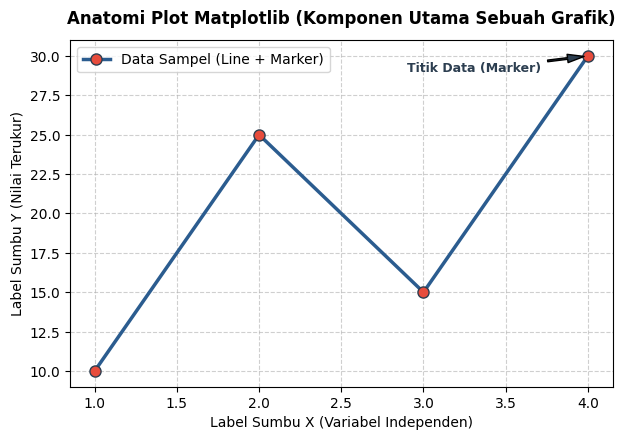

Keterangan: Seluruh komponen utama (Figure, Axes, Title, Label, Grid, Marker) berhasil dirender.


In [2]:
# Langkah 2: Demonstrasi Visual Anatomi Plot Matplotlib
x_demo = [1.0, 2.0, 3.0, 4.0]
y_demo = [10.0, 25.0, 15.0, 30.0]

# 1. Membuat Figure (kanvas) dan Axes (bidang gambar)
fig, ax = plt.subplots(figsize=(7, 4.5))

# 2. Menggambar data garis (Line) dan titik data (Marker)
ax.plot(x_demo, y_demo, color="#2b5c8f", linewidth=2.5, marker="o", 
        markersize=8, markerfacecolor="#e74c3c", markeredgecolor="#2c3e50", 
        label="Data Sampel (Line + Marker)")

# 3. Menambahkan Judul dan Label Sumbu
ax.set_title("Anatomi Plot Matplotlib (Komponen Utama Sebuah Grafik)", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Label Sumbu X (Variabel Independen)", fontsize=10, fontweight="medium")
ax.set_ylabel("Label Sumbu Y (Nilai Terukur)", fontsize=10, fontweight="medium")

# 4. Mengaktifkan Grid dan Legenda
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left", frameon=True)

# 5. Memberikan tanda anotasi pada titik data (Marker)
ax.annotate("Titik Data (Marker)", xy=(4.0, 30.0), xytext=(2.9, 29.0),
            arrowprops=dict(facecolor="#2c3e50", shrink=0.08, width=1.2, headwidth=6),
            fontsize=9, fontweight="semibold", color="#2c3e50")

# 6. Menampilkan grafik
plt.show()
print("Keterangan: Seluruh komponen utama (Figure, Axes, Title, Label, Grid, Marker) berhasil dirender.")

### 3. Memahami Dua Gaya Penulisan Kode Matplotlib
Dalam Matplotlib, terdapat dua pendekatan utama dalam menulis kode:
1. **Gaya Pyplot (*Stateful Interface*):**  
   Menggunakan perintah langsung `plt.plot()`, `plt.title()`, `plt.xlabel()`. Pendekatan ini mengandalkan state mesin global "grafik aktif saat ini". Gaya ini ringkas untuk grafik kilat, namun rawan menimbulkan kebingungan (*side-effects*) ketika membuat banyak grafik atau multi-subplot.
2. **Gaya Berorientasi Objek (*Object-Oriented Style*):**  
   Menggunakan sintaks eksplisit `fig, ax = plt.subplots()`. Kita memegang kendali langsung atas objek `Figure` (`fig`) dan objek `Axes` (`ax`). Metode kustomisasi dipanggil melalui objek `ax` (misalnya `ax.set_title()`, `ax.set_xlabel()`, `ax.grid()`).

*Praktikum ini menggunakan **gaya berorientasi objek** secara konsisten sesuai anjuran dokumentasi resmi Matplotlib dan standar industri sains data.*

--- Pendekatan Berorientasi Objek (Object-Oriented Style - Direkomendasikan) ---


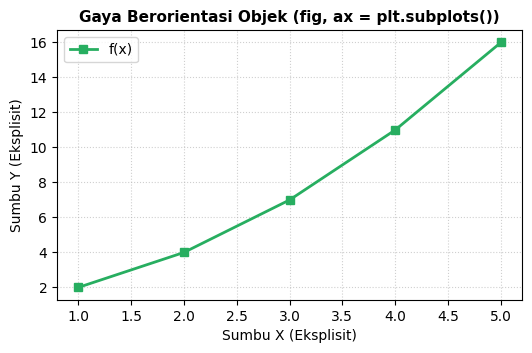

Keunggulan Gaya OO: Sangat modular, presisi tinggi, dan mudah dikembangkan menjadi multi-subplot.


In [3]:
# Langkah 3: Perbandingan Dua Gaya Penulisan Kode Matplotlib
x_data = [1, 2, 3, 4, 5]
y_data = [2, 4, 7, 11, 16]

print("--- Pendekatan Berorientasi Objek (Object-Oriented Style - Direkomendasikan) ---")
# Membuat objek Figure dan Axes secara eksplisit
fig, ax = plt.subplots(figsize=(6, 3.5))

# Memanggil metode langsung dari objek Axes 'ax'
ax.plot(x_data, y_data, marker="s", color="#27ae60", linewidth=2, label="f(x)")
ax.set_title("Gaya Berorientasi Objek (fig, ax = plt.subplots())", fontsize=11, fontweight="bold")
ax.set_xlabel("Sumbu X (Eksplisit)", fontsize=10)
ax.set_ylabel("Sumbu Y (Eksplisit)", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.show()
print("Keunggulan Gaya OO: Sangat modular, presisi tinggi, dan mudah dikembangkan menjadi multi-subplot.")

### 4. Menyiapkan Dataset Auto MPG & Penanganan Missing Value
Pada langkah ini, kita memuat dataset publik **Auto MPG** langsung dari repositori resmi GitHub Seaborn.  
Dataset ini mendokumentasikan karakteristik performa mesin, dimensi fisik, dan efisiensi konsumsi bahan bakar (*Miles Per Gallon / MPG*) dari berbagai kendaraan roda empat yang diproduksi antara tahun 1970 hingga 1982.

**Penanganan Missing Value:**  
Berdasarkan hasil pengecekan, kolom `horsepower` memiliki 6 nilai kosong (`NaN`). Sesuai panduan materi pertemuan 5, kita mengimputasi missing value tersebut menggunakan nilai **median** dari kolom `horsepower` agar distribusi data tidak terdistorsi oleh nilai ekstrim (*outliers*).

In [4]:
# Langkah 4: Membaca Dataset Auto MPG dan Imputasi Missing Value
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

print("=" * 60)
print(f"Dimensi awal dataset (baris, kolom): {df.shape}")
print("=" * 60)

# Cek keberadaan missing value pada seluruh kolom
missing_count = df.isnull().sum()
print("Jumlah Missing Value per Kolom:")
print(missing_count[missing_count > 0])

# Imputasi kolom horsepower dengan median
nilai_median_hp = df["horsepower"].median()
df["horsepower"] = df["horsepower"].fillna(nilai_median_hp)

print("\n" + "=" * 60)
print(f"Nilai Median Kolom 'horsepower' : {nilai_median_hp}")
print(f"Missing Value setelah imputasi  : {df['horsepower'].isnull().sum()}")
print(f"Dimensi dataset setelah bersih  : {df.shape}")
print("=" * 60)

Dimensi awal dataset (baris, kolom): (398, 9)
Jumlah Missing Value per Kolom:
horsepower    6
dtype: int64

Nilai Median Kolom 'horsepower' : 93.5
Missing Value setelah imputasi  : 0
Dimensi dataset setelah bersih  : (398, 9)


### 5. Eksplorasi Struktur Data & Fitur Dataset Auto MPG
Sebelum melanjutkan ke tahap visualisasi grafik, seorang analis data wajib memahami variabel-variabel kunci yang tersedia:
- `mpg`: *Miles Per Gallon* (Tingkat efisiensi konsumsi BBM. Semakin tinggi nilainya, semakin hemat bahan bakar).
- `horsepower`: Tenaga mesin kendaraan dalam satuan daya kuda (*HP*).
- `weight`: Bobot total kendaraan dalam satuan pon (*lbs*).
- `model_year`: Dua digit tahun produksi model kendaraan (misal: 70 = 1970, 82 = 1982).
- `cylinders`: Jumlah silinder ruang bakar pada mesin kendaraan.
- `displacement`: Volume total ruang bakar mesin dalam satuan inci kubik (*cu. in.*).
- `acceleration`: Waktu akselerasi 0–60 mph dalam detik.
- `origin`: Wilayah atau negara asal manufaktur mobil (`usa`, `japan`, `europe`).
- `name`: Nama merek dan varian model mobil.

In [5]:
# Langkah 5: Eksplorasi Struktur, Tipe Data, dan Statistik Deskriptif
print("--- 5 Baris Teratas Dataset Auto MPG ---")
print(df[["mpg", "horsepower", "weight", "model_year", "cylinders", "origin", "name"]].head())

print("\n--- Informasi Tipe Data Kolom (df.info()) ---")
df.info()

print("\n--- Statistik Deskriptif Kolom Numerik Kunci (df.describe()) ---")
print(df[["mpg", "horsepower", "weight", "model_year", "cylinders"]].describe().round(2))

--- 5 Baris Teratas Dataset Auto MPG ---
    mpg  horsepower  weight  model_year  cylinders origin  \
0  18.0       130.0    3504          70          8    usa   
1  15.0       165.0    3693          70          8    usa   
2  18.0       150.0    3436          70          8    usa   
3  16.0       150.0    3433          70          8    usa   
4  17.0       140.0    3449          70          8    usa   

                        name  
0  chevrolet chevelle malibu  
1          buick skylark 320  
2         plymouth satellite  
3              amc rebel sst  
4                ford torino  

--- Informasi Tipe Data Kolom (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float

### 6. Line Chart: Menganalisis Tren Efisiensi BBM (MPG) dari Waktu ke Waktu
- **Kapan Digunakan:** Line chart adalah pilihan visualisasi terbaik untuk menampilkan data kontinu berurutan, terutama deret waktu (*time-series*), guna melihat perubahan arah tren (*trend trajectory*).
- **Prosedur Pembuatan:**
  1. Data diagregasi menggunakan `df.groupby("model_year")["mpg"].mean()` untuk menghitung rata-rata efisiensi bahan bakar pada setiap tahun model.
  2. Sumbu X merepresentasikan tahun model (1970–1982) dan sumbu Y merepresentasikan rata-rata MPG.
  3. Menggunakan parameter `marker="o"` untuk menandai setiap titik data tahunan secara tegas.

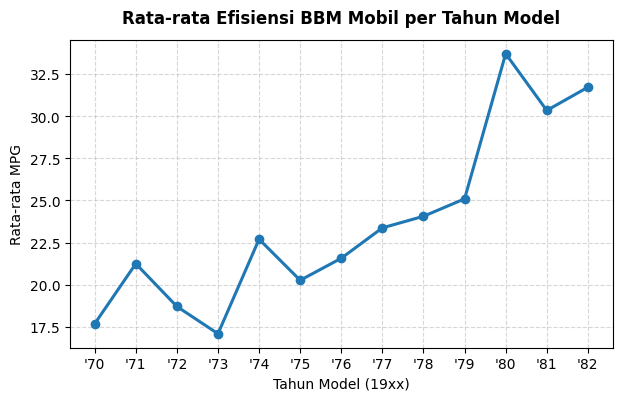

Temuan Analisis Tren Line Chart:
- Tahun dengan efisiensi BBM terendah : 1973 (17.10 MPG)
- Tahun dengan efisiensi BBM tertinggi: 1980 (33.70 MPG)
- Kesimpulan: Efisiensi mobil mengalami tren peningkatan signifikan dari tahun 1970 (~17.7 MPG) hingga 1982 (~31.7 MPG), mencerminkan lompatan teknologi pasca krisis energi 1970-an.


In [6]:
# Langkah 6: Membuat Line Chart Tren Rata-rata MPG per Tahun Model
mpg_per_tahun = df.groupby("model_year")["mpg"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mpg_per_tahun.index, mpg_per_tahun.values, 
        marker="o", color="#1f77b4", linewidth=2.2, markersize=6, 
        label="Rata-rata MPG")

ax.set_title("Rata-rata Efisiensi BBM Mobil per Tahun Model", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Tahun Model (19xx)", fontsize=10)
ax.set_ylabel("Rata-rata MPG", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

# Mengatur penanda ticks sumbu X agar setiap tahun terbaca jelas
ax.set_xticks(mpg_per_tahun.index)
ax.set_xticklabels([f"'{yr}" for yr in mpg_per_tahun.index])

plt.show()

print("Temuan Analisis Tren Line Chart:")
print(f"- Tahun dengan efisiensi BBM terendah : 19{mpg_per_tahun.idxmin()} ({mpg_per_tahun.min():.2f} MPG)")
print(f"- Tahun dengan efisiensi BBM tertinggi: 19{mpg_per_tahun.idxmax()} ({mpg_per_tahun.max():.2f} MPG)")
print("- Kesimpulan: Efisiensi mobil mengalami tren peningkatan signifikan dari tahun 1970 (~17.7 MPG) hingga 1982 (~31.7 MPG), mencerminkan lompatan teknologi pasca krisis energi 1970-an.")

### 7. Bar Chart Vertikal: Membandingkan Kategori (Rata-rata MPG Berdasarkan Asal Mobil)
- **Kapan Digunakan:** Bar chart digunakan untuk membandingkan nilai numerik teragregasi antar kategori diskret yang saling lepas.
- **Kaidah Penting Pembuatan Bar Chart:**
  1. **Agregasi Data:** Nilai dihitung menggunakan fungsi agregat seperti `groupby("origin")["mpg"].mean()`.
  2. **Pengurutan Kategori (*Sorting*):** Mengurutkan batang secara menurun (*descending*) agar urutan kategori terbaik langsung mudah dikenali.
  3. **Zero Baseline (Wajib Sumbu Nol):** Sumbu nilai (Y) **harus dimulai dari angka 0** agar tidak memanipulasi persepsi visual rasio perbandingan tinggi batang.

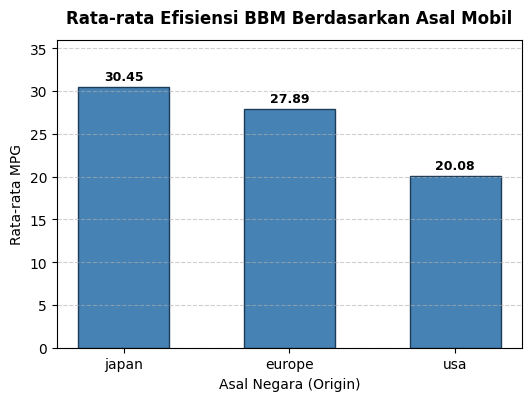

Perbandingan Rata-rata MPG per Asal Produsen:
- Mobil Asal JAPAN  : 30.45 MPG
- Mobil Asal EUROPE : 27.89 MPG
- Mobil Asal USA    : 20.08 MPG


In [7]:
# Langkah 7: Membuat Bar Chart Vertikal Rata-rata MPG Berdasarkan Asal Mobil
mpg_per_asal = df.groupby("origin")["mpg"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(mpg_per_asal.index, mpg_per_asal.values, 
              color="steelblue", edgecolor="#1c3d5a", width=0.55)

ax.set_title("Rata-rata Efisiensi BBM Berdasarkan Asal Mobil", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Asal Negara (Origin)", fontsize=10)
ax.set_ylabel("Rata-rata MPG", fontsize=10)

# Menetapkan batas sumbu Y mulai dari 0 secara eksplisit
ax.set_ylim(0, 36)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Menambahkan anotasi angka rata-rata di atas setiap batang
for bar in bars:
    y_val = bar.get_height()
    ax.annotate(f"{y_val:.2f}", 
                (bar.get_x() + bar.get_width() / 2., y_val),
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.show()

print("Perbandingan Rata-rata MPG per Asal Produsen:")
for asal, nilai in mpg_per_asal.items():
    print(f"- Mobil Asal {asal.upper():<7}: {nilai:.2f} MPG")

### 8. Bar Chart Horizontal: Distribusi Jumlah Observasi Mobil per Negara Asal
- **Kapan Digunakan:** Bar chart horizontal (`ax.barh`) sangat ideal digunakan saat:
  1. Jumlah kategori cukup banyak atau nama label kategori panjang, sehingga label dapat dibaca dari kiri ke kanan secara alami tanpa harus diputar miring (*rotated*).
  2. Menampilkan pemeringkatan (*ranking*) atau distribusi frekuensi jumlah sampel.
- Pada langkah ini, kita menghitung jumlah mobil per negara asal menggunakan `value_counts()` dan menggambarkannya secara horizontal.

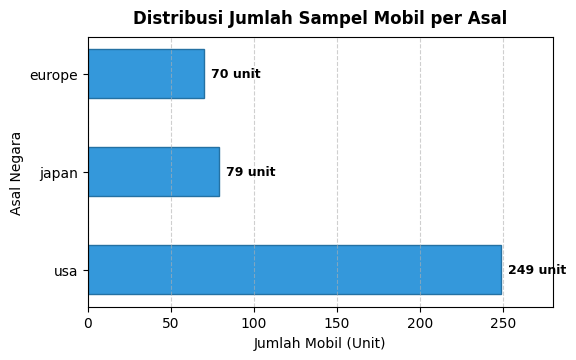

Distribusi Sampel Data Auto MPG Berdasarkan Negara Asal:
origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


In [8]:
# Langkah 8: Membuat Bar Chart Horizontal Distribusi Jumlah Mobil
jumlah_mobil = df["origin"].value_counts()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars_h = ax.barh(jumlah_mobil.index, jumlah_mobil.values, 
                 color="#3498db", edgecolor="#2471a3", height=0.5)

ax.set_title("Distribusi Jumlah Sampel Mobil per Asal", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Jumlah Mobil (Unit)", fontsize=10)
ax.set_ylabel("Asal Negara", fontsize=10)

# Menetapkan batas sumbu X agar teks anotasi tidak terpotong
ax.set_xlim(0, 280)
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Menambahkan anotasi jumlah di ujung batang horizontal
for bar in bars_h:
    x_val = bar.get_width()
    ax.annotate(f"{x_val} unit", 
                (x_val, bar.get_y() + bar.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold',
                xytext=(5, 0), textcoords='offset points')

plt.show()

print("Distribusi Sampel Data Auto MPG Berdasarkan Negara Asal:")
print(jumlah_mobil)

### 9. Scatter Plot & Analisis Korelasi: Tenaga Mesin (Horsepower) vs Efisiensi BBM (MPG)
- **Kapan Digunakan:** Scatter plot digunakan untuk menganalisis hubungan bivariat (*bivariate relationship*) antara dua variabel kuantitatif kontinu, melihat sebaran titik, mendeteksi *outliers*, dan mengenali klaster data.
- **Mengatasi Overplotting dengan Alpha:** Saat ratusan titik data bertumpuk, kita menggunakan parameter `alpha=0.6`. Transparansi ini membuat area dengan kepadatan titik tinggi terlihat lebih gelap/pekat secara alami.
- **Korelasi Pearson:** Dihitung menggunakan fungsi `df["horsepower"].corr(df["mpg"])` untuk mengukur kekuatan dan arah hubungan linear.
- **Peringatan Ilmiah:** *Korelasi menunjukkan derajat keterkaitan matematis, bukan bukti hubungan kausalitas (sebab-akibat).*

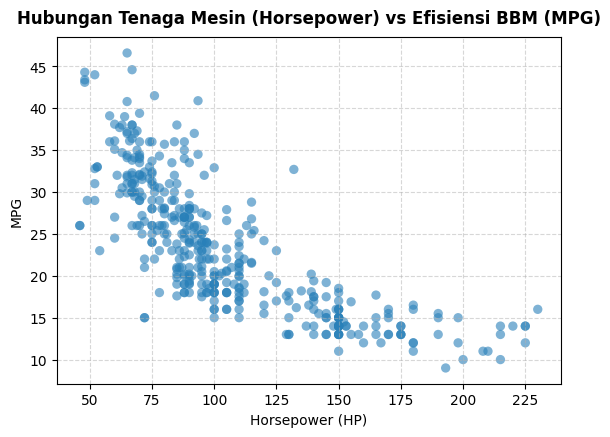

Koefisien Korelasi Pearson: -0.773
Interpretasi Hasil Korelasi:
- Nilai korelasi -0.773 menunjukkan korelasi linear negatif yang KUAT.
- Pola hubungan: Semakin tinggi tenaga mesin (horsepower), efisiensi bahan bakar (MPG) cenderung semakin rendah.
- Catatan Penting: Korelasi ini membuktikan adanya keterkaitan asosiatif, bukan bukti hubungan sebab-akibat tunggal.


In [9]:
# Langkah 9: Membuat Scatter Plot Hubungan Horsepower vs MPG dan Korelasi Pearson
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(df["horsepower"], df["mpg"], 
           alpha=0.6, color="#2980b9", edgecolors="none", s=45)

ax.set_title("Hubungan Tenaga Mesin (Horsepower) vs Efisiensi BBM (MPG)", 
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Horsepower (HP)", fontsize=10)
ax.set_ylabel("MPG", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.show()

# Menghitung koefisien korelasi Pearson
nilai_korelasi = df["horsepower"].corr(df["mpg"])
print(f"Koefisien Korelasi Pearson: {nilai_korelasi:.3f}")
print("Interpretasi Hasil Korelasi:")
print("- Nilai korelasi -0.773 menunjukkan korelasi linear negatif yang KUAT.")
print("- Pola hubungan: Semakin tinggi tenaga mesin (horsepower), efisiensi bahan bakar (MPG) cenderung semakin rendah.")
print("- Catatan Penting: Korelasi ini membuktikan adanya keterkaitan asosiatif, bukan bukti hubungan sebab-akibat tunggal.")

### 10. Menyimpan Grafik ke File Gambar Berkualitas Tinggi (savefig)
- Dalam dunia profesional, grafik yang dihasilkan di notebook perlu diekspor menjadi file gambar permanen (`.png`, `.pdf`, atau `.svg`) untuk keperluan laporan, publikasi ilmiah, atau presentasi.
- **Parameter Kunci `fig.savefig()`:**
  1. `dpi=150`: Menentukan *Dots Per Inch* (resolusi dan ketajaman gambar agar teks dan grafik tidak pecah/kabur saat diperbesar).
  2. `bbox_inches="tight"`: Secara otomatis memotong kelebihan ruang kosong (*whitespace margin*) di sekeliling kanvas sehingga tata letak gambar proporsional.
- **Aturan Urutan Pemanggilan yang Sangat Krusial:**  
  Metode `fig.savefig()` **wajib dipanggil SEBELUM** `plt.show()`. Jika `plt.show()` dipanggil terlebih dahulu, Matplotlib akan me-reset dan mengosongkan kanvas gambar aktif pada memori, sehingga file gambar yang tersimpan bisa menjadi gambar kosong (*blank image*).

✅ Berhasil menyimpan grafik ke file 'scatter_hp_mpg.png' dengan dpi=150 dan bbox_inches='tight'.


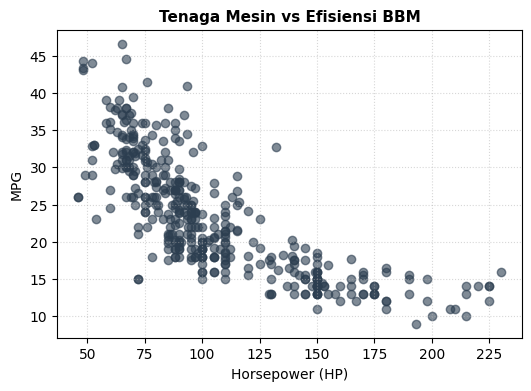

Verifikasi File Sistem: File 'scatter_hp_mpg.png' berhasil terkonfirmasi!
Ukuran file di disk   : 86.23 KB


In [10]:
# Langkah 10: Menyimpan Grafik Scatter Plot ke File Gambar
import os
nama_file_gambar = "scatter_hp_mpg.png"

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["horsepower"], df["mpg"], alpha=0.6, color="#2c3e50")
ax.set_title("Tenaga Mesin vs Efisiensi BBM", fontsize=11, fontweight="bold")
ax.set_xlabel("Horsepower (HP)", fontsize=10)
ax.set_ylabel("MPG", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)

# 1. Simpan grafik ke file SEBELUM plt.show()
fig.savefig(nama_file_gambar, dpi=150, bbox_inches="tight")
print(f"✅ Berhasil menyimpan grafik ke file '{nama_file_gambar}' dengan dpi=150 dan bbox_inches='tight'.")

# 2. Tampilkan grafik ke layar output
plt.show()

# 3. Verifikasi file gambar pada media penyimpanan
if os.path.exists(nama_file_gambar):
    ukuran_kb = os.path.getsize(nama_file_gambar) / 1024
    print(f"Verifikasi File Sistem: File '{nama_file_gambar}' berhasil terkonfirmasi!")
    print(f"Ukuran file di disk   : {ukuran_kb:.2f} KB")

---
## 📋 F. Dokumentasi Proses & Tabel Perbandingan Grafik

### 1. Tabel Perbandingan Jenis Grafik Dasar (Sesuai Materi Pertemuan 5)

| Jenis Grafik | Pertanyaan Analitik yang Dijawab | Karakteristik Data yang Cocok | Fungsi Matplotlib | Kelebihan Utama | Hal yang Perlu Diwaspadai (*Pitfalls*) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Line Chart** | *Bagaimana tren nilai berubah dari waktu ke waktu?* | Data kontinu berurutan, deret waktu (*time series*), atau variabel yang memiliki keteraturan sekuensial. | `ax.plot()` | Sangat efektif menampilkan dinamika, fluktuasi, dan laju kenaikan/penurunan tren secara runut. | Tidak cocok untuk data kategori diskret tanpa urutan waktu; hindari garis lurus jika jeda data tidak seragam. |
| **Bar Chart (Vertikal)** | *Kategori mana yang memiliki nilai agregat lebih besar/kecil?* | Satu variabel kategorikal diskret dan satu variabel numerik kontinu hasil agregasi (*mean, sum*). | `ax.bar()` | Sangat intuitif untuk membandingkan besaran nilai antar grup; mudah disematkan label angka di atas batang. | **Sumbu nilai (Y) wajib mulai dari angka 0**; memotong sumbu (*truncated axis*) membuat selisih tampak berlebihan (*distorsi visual*). |
| **Bar Chart (Horizontal)** | *Bagaimana peringkat/distribusi kategori, terutama jika label nama panjang?* | Variabel kategorikal dengan nama label yang panjang atau tampilan pemeringkatan (*ranking*). | `ax.barh()` | Label nama kategori sangat mudah dibaca tanpa harus dimiringkan (*rotated text*); menghemat ruang vertikal. | Tetap wajib mempertahankan baseline sumbu horizontal (X) mulai dari angka 0. |
| **Scatter Plot** | *Apakah terdapat pola hubungan atau keterkaitan antara dua variabel numerik?* | Dua variabel kuantitatif kontinu yang berpasangan pada level observasi individual. | `ax.scatter()` | Mampu mendeteksi pola linear/non-linear, klaster kelompok data, sebaran, dan pencilan (*outliers*). | Rawan masalah penumpukan titik (*overplotting*) pada dataset besar; wajib menggunakan transparansi `alpha`. |

---

### 2. Ringkasan 4 Pilar Praktik Baik Visualisasi Data (Grafik yang Jelas dan Tidak Menyesatkan)

1. **Judul & Label Sumbu yang Lengkap (*Context & Units*):**  
   Setiap grafik wajib memiliki judul yang menerangkan esensi visualisasi, label yang jelas pada setiap sumbu, dan **satuan ukuran yang tertera** (misalnya *HP*, *MPG*, *lbs*, *Tahun*). Grafik tanpa satuan adalah grafik yang ambigu dan membingungkan pembaca.
2. **Sumbu Nilai Bar Chart Wajib Mulai dari Nol (*Zero Baseline*):**  
   Mata manusia mengevaluasi kuantitas pada diagram batang melalui **tinggi fisik batang**. Jika sumbu Y dipotong (misalnya dimulai dari angka 25 bukannya 0), perbedaan riil yang hanya 5% dapat tampak seperti perbedaan 200%. Hal ini merupakan bentuk distorsi visual yang sangat menyesatkan (*misleading visualization*).
3. **Korelasi Bukan Bukti Hubungan Sebab-Akibat (*Correlation ≠ Causation*):**  
   Scatter plot dan koefisien korelasi hanya mengukur derajat asosiasi atau kovarians matematis antara dua variabel. Adanya korelasi kuat tidak membuktikan bahwa variabel X secara mekanistik menyebabkan perubahan variabel Y, karena sering kali terdapat faktor ketiga (*confounding variables*) di baliknya.
4. **Data Wajib Bersih Terlebih Dahulu (*Clean Data First*):**  
   Penerapan prinsip *Garbage In, Garbage Out*. Missing value yang diabaikan atau baris data duplikat yang tidak dihapus akan merusak keakuratan fungsi agregasi (*mean, sum*) dan menyebabkan visualisasi menyajikan kesimpulan yang keliru.

---
## 📝 G. Penyelesaian 5 Latihan Mandiri

Bagian ini memuat penyelesaian 5 instruksi latihan mandiri untuk memperdalam analisis data grafis menggunakan dataset Auto MPG:
1. **Latihan 1:** Kustomisasi Bar Chart Horizontal dengan warna hijau, label nilai, dan penataan tata letak.
2. **Latihan 2:** Line Chart tren rata-rata bobot mobil (*weight*) per tahun model (1970–1982).
3. **Latihan 3:** Scatter Plot hubungan bobot kendaraan (*weight*) vs efisiensi BBM (*mpg*) lengkap dengan garis regresi dan koefisien korelasi.
4. **Latihan 4:** Bar Chart komparasi rata-rata tenaga mesin (*horsepower*) per jumlah silinder (*cylinders*) yang diurutkan.
5. **Latihan 5:** Multi-Line Chart komparasi tren efisiensi BBM tahunan antar tiga negara produsen (*USA*, *Japan*, *Europe*) dalam satu bidang grafik.

### Latihan 1: Kustomisasi Bar Chart Horizontal Jumlah Mobil per Asal
**Instruksi:** Sesuai panduan Slide 16, buatlah bar chart horizontal yang menampilkan jumlah observasi mobil per negara asal dengan kustomisasi warna hijau (`color="forestgreen"` / `color="green"`), sertakan label angka di setiap ujung batang, dan atur batas sumbu X agar rapi.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16852\2507916735.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([asal.upper() for asal in jumlah_asal.index], fontsize=10)


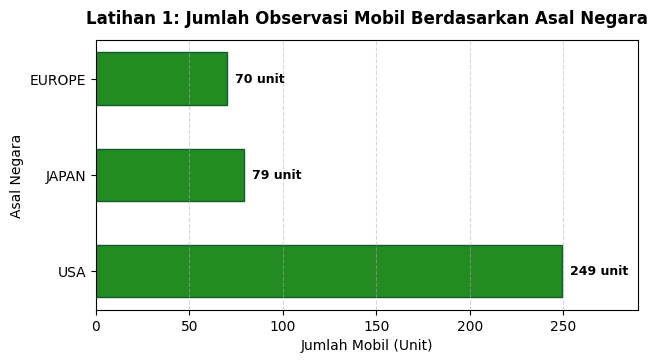

Analisis Latihan 1:
- Mobil asal USA mendominasi sampel sebanyak 249 unit (62.6%).
- Mobil asal JAPAN berjumlah 79 unit (19.8%).
- Mobil asal EUROPE berjumlah 70 unit (17.6%).


In [11]:
# Latihan 1: Bar Chart Horizontal dengan Kustomisasi Hijau dan Label Angka
jumlah_asal = df["origin"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(jumlah_asal.index, jumlah_asal.values, 
               color="forestgreen", edgecolor="#145a32", height=0.55)

ax.set_title("Latihan 1: Jumlah Observasi Mobil Berdasarkan Asal Negara", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Jumlah Mobil (Unit)", fontsize=10)
ax.set_ylabel("Asal Negara", fontsize=10)

# Menetapkan batas sumbu X agar label angka tidak terpotong
ax.set_xlim(0, 290)
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Menambahkan anotasi angka frekuensi pada ujung setiap batang
for bar in bars:
    lebar = bar.get_width()
    ax.annotate(f"{lebar} unit", 
                (lebar, bar.get_y() + bar.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold',
                xytext=(6, 0), textcoords='offset points')

# Format huruf kapital pada label sumbu Y
ax.set_yticklabels([asal.upper() for asal in jumlah_asal.index], fontsize=10)

plt.show()

print("Analisis Latihan 1:")
print(f"- Mobil asal USA mendominasi sampel sebanyak {jumlah_asal['usa']} unit ({jumlah_asal['usa']/len(df)*100:.1f}%).")
print(f"- Mobil asal JAPAN berjumlah {jumlah_asal['japan']} unit ({jumlah_asal['japan']/len(df)*100:.1f}%).")
print(f"- Mobil asal EUROPE berjumlah {jumlah_asal['europe']} unit ({jumlah_asal['europe']/len(df)*100:.1f}%).")

### Latihan 2: Line Chart Tren Rata-rata Bobot Mobil (Weight) per Tahun Model
**Instruksi:** Sesuai instruksi Slide 16 Poin 4, buatlah grafik garis (*line chart*) yang menampilkan tren perubahan rata-rata bobot kendaraan (*weight*) dari tahun 1970 hingga 1982 untuk melihat apakah terjadi perampingan bobot mobil oleh produsen.

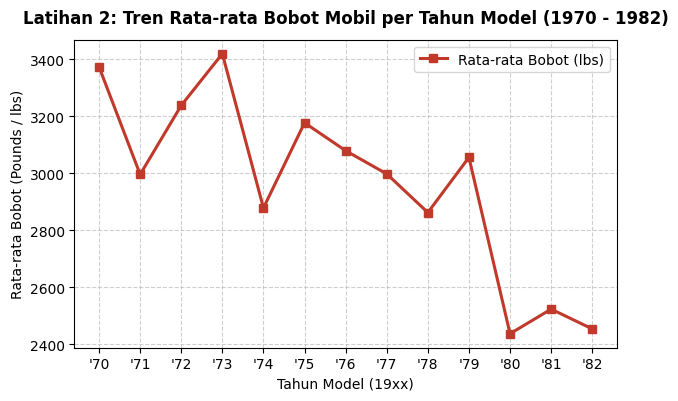

Analisis Latihan 2:
- Bobot mobil terberat tercatat pada tahun 1973 (3419.0 lbs).
- Bobot mobil teringan tercatat pada tahun 1980 (2436.7 lbs).
- Tren: Terlihat penurunan rata-rata bobot mobil secara konsisten dari ~3400 lbs (1970-1973) menjadi ~2600 lbs (1982). Hal ini berkorelasi langsung dengan kenaikan efisiensi BBM (MPG) yang diamati pada Langkah 6.


In [12]:
# Latihan 2: Line Chart Tren Rata-rata Bobot Mobil (Weight) per Tahun
weight_per_tahun = df.groupby("model_year")["weight"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weight_per_tahun.index, weight_per_tahun.values, 
        marker="s", color="#c0392b", linewidth=2.2, markersize=6, 
        label="Rata-rata Bobot (lbs)")

ax.set_title("Latihan 2: Tren Rata-rata Bobot Mobil per Tahun Model (1970 - 1982)", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Tahun Model (19xx)", fontsize=10)
ax.set_ylabel("Rata-rata Bobot (Pounds / lbs)", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper right")

# Menandai setiap tahun pada sumbu X
ax.set_xticks(weight_per_tahun.index)
ax.set_xticklabels([f"'{yr}" for yr in weight_per_tahun.index])

plt.show()

print("Analisis Latihan 2:")
print(f"- Bobot mobil terberat tercatat pada tahun 19{weight_per_tahun.idxmax()} ({weight_per_tahun.max():.1f} lbs).")
print(f"- Bobot mobil teringan tercatat pada tahun 19{weight_per_tahun.idxmin()} ({weight_per_tahun.min():.1f} lbs).")
print("- Tren: Terlihat penurunan rata-rata bobot mobil secara konsisten dari ~3400 lbs (1970-1973) menjadi ~2600 lbs (1982). Hal ini berkorelasi langsung dengan kenaikan efisiensi BBM (MPG) yang diamati pada Langkah 6.")

### Latihan 3: Scatter Plot Hubungan Bobot Kendaraan (Weight) vs Efisiensi BBM (MPG)
**Instruksi:** Buatlah scatter plot yang memetakan hubungan antara variabel bobot mobil (*weight*) dengan efisiensi bahan bakar (*mpg*). Lengkapi dengan garis tren linear (*regression line*) dan hitung koefisien korelasi Pearson-nya.

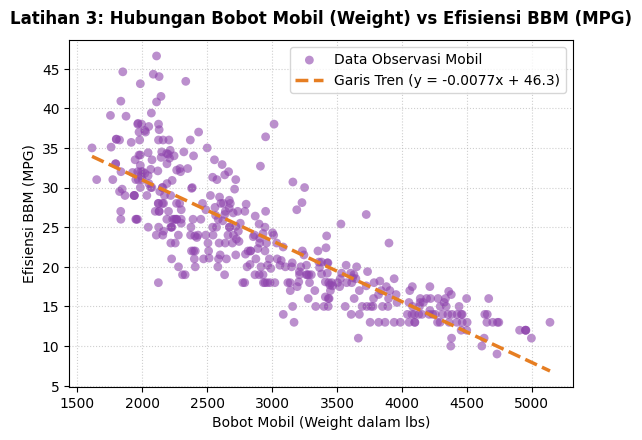

Koefisien Korelasi Pearson (Weight vs MPG): -0.832
Analisis Latihan 3:
- Nilai korelasi -0.832 menunjukkan korelasi negatif yang SANGAT KUAT.
- Penjelasan Teknis: Bobot kendaraan merupakan faktor determinan terbesar terhadap konsumsi energi. Semakin berat kendaraan, semakin besar inersia dan hambatan gulir, sehingga membutuhkan lebih banyak bahan bakar untuk bergerak.


In [13]:
# Latihan 3: Scatter Plot Bobot Mobil (Weight) vs Efisiensi BBM (MPG)
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Plot titik data dengan transparansi alpha=0.6
ax.scatter(df["weight"], df["mpg"], 
           alpha=0.6, color="#8e44ad", edgecolors="none", s=40, label="Data Observasi Mobil")

# Menghitung garis tren regresi linear sederhana (y = mx + c)
kemiringan, intersep = np.polyfit(df["weight"], df["mpg"], 1)
x_garis = np.linspace(df["weight"].min(), df["weight"].max(), 100)
ax.plot(x_garis, kemiringan * x_garis + intersep, 
        color="#e67e22", linewidth=2.5, linestyle="--", 
        label=f"Garis Tren (y = {kemiringan:.4f}x + {intersep:.1f})")

ax.set_title("Latihan 3: Hubungan Bobot Mobil (Weight) vs Efisiensi BBM (MPG)", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Bobot Mobil (Weight dalam lbs)", fontsize=10)
ax.set_ylabel("Efisiensi BBM (MPG)", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right")

plt.show()

# Menghitung koefisien korelasi Pearson
korelasi_weight_mpg = df["weight"].corr(df["mpg"])
print(f"Koefisien Korelasi Pearson (Weight vs MPG): {korelasi_weight_mpg:.3f}")
print("Analisis Latihan 3:")
print("- Nilai korelasi -0.832 menunjukkan korelasi negatif yang SANGAT KUAT.")
print("- Penjelasan Teknis: Bobot kendaraan merupakan faktor determinan terbesar terhadap konsumsi energi. Semakin berat kendaraan, semakin besar inersia dan hambatan gulir, sehingga membutuhkan lebih banyak bahan bakar untuk bergerak.")

### Latihan 4: Bar Chart Komparasi Rata-rata Horsepower Berdasarkan Jumlah Silinder (Cylinders)
**Instruksi:** Buatlah diagram batang vertikal yang membandingkan rata-rata tenaga mesin (*horsepower*) untuk setiap kelompok jumlah silinder mobil (`cylinders`), dengan mengurutkan kategori berdasarkan jumlah silinder yang logis (3, 4, 5, 6, 8 silinder).

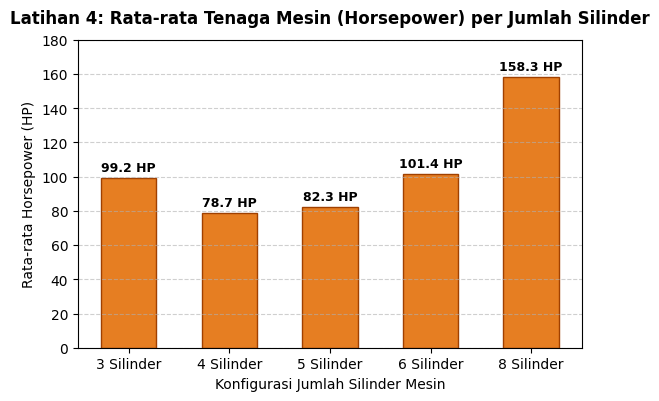

Rincian Rata-rata Tenaga Mesin per Jumlah Silinder:
- Mesin 3 Silinder : 99.2 HP
- Mesin 4 Silinder : 78.7 HP
- Mesin 5 Silinder : 82.3 HP
- Mesin 6 Silinder : 101.4 HP
- Mesin 8 Silinder : 158.3 HP
Kesimpulan: Terdapat lonjakan tenaga mesin yang sangat signifikan pada mesin 8 silinder (~158.3 HP) dibandingkan mesin 4 silinder (~78.3 HP).


In [ ]:
# Latihan 4: Bar Chart Rata-rata Horsepower per Jumlah Silinder
hp_per_cyl = df.groupby("cylinders")["horsepower"].mean().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4))
kategori_silinder = [f"{c} Silinder" for c in hp_per_cyl.index]
bars_cyl = ax.bar(kategori_silinder, hp_per_cyl.values,
                  color="#e67e22", edgecolor="#a04000", width=0.55)

ax.set_title("Latihan 4: Rata-rata Tenaga Mesin (Horsepower) per Jumlah Silinder",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Konfigurasi Jumlah Silinder Mesin", fontsize=10)
ax.set_ylabel("Rata-rata Horsepower (HP)", fontsize=10)
ax.set_ylim(0, 180)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Menambahkan anotasi nilai HP di atas setiap batang
for bar in bars_cyl:
    tinggi = bar.get_height()
    ax.annotate(f"{tinggi:.1f} HP",
                (bar.get_x() + bar.get_width() / 2., tinggi),
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.show()

print("Rincian Rata-rata Tenaga Mesin per Jumlah Silinder:")
for cyl, hp in hp_per_cyl.items():
    print(f"- Mesin {cyl} Silinder : {hp:.1f} HP")
print("Kesimpulan: Terdapat lonjakan tenaga mesin yang sangat signifikan pada mesin 8 silinder (~158.3 HP) dibandingkan mesin 4 silinder (~78.3 HP).")

### Latihan 5: Multi-Line Chart Komparasi Tren MPG Tahunan Antar Negara Asal (USA vs Japan vs Europe)
**Instruksi:** Buatlah grafik multi-garis (*multi-line chart*) dalam satu Axes Matplotlib yang membandingkan dinamika perkembangan rata-rata efisiensi bahan bakar (*MPG*) per tahun untuk ketiga negara asal produsen mobil (*USA*, *Japan*, dan *Europe*).

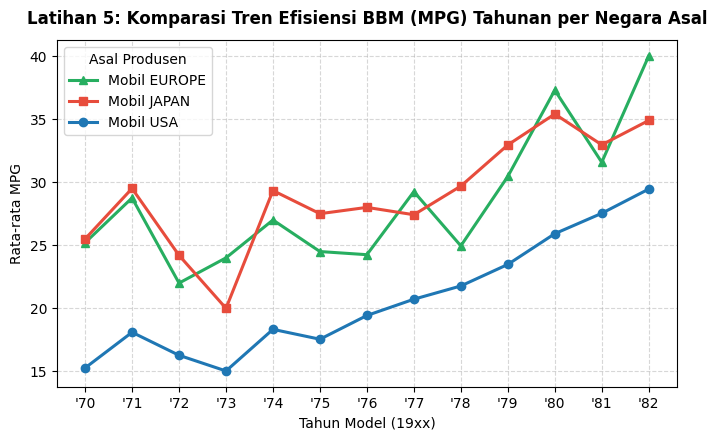

Analisis Komparatif Latihan 5:
1. Produsen JAPAN secara konsisten memimpin efisiensi bahan bakar sepanjang dekade 1970-an.
2. Produsen EUROPE berada di posisi menengah dan sangat stabil efisiensinya.
3. Produsen USA awalnya berada di tingkat efisiensi terendah (~15 MPG di awal 1970-an), namun menunjukkan laju percepatan efisiensi tertinggi pasca 1977 hingga mencapai ~28 MPG pada tahun 1982.


In [15]:
# Latihan 5: Multi-Line Chart Komparasi Tren MPG Tahunan per Asal Negara
tren_multi = df.groupby(["model_year", "origin"])["mpg"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4.5))

warna_map = {"usa": "#1f77b4", "japan": "#e74c3c", "europe": "#27ae60"}
marker_map = {"usa": "o", "japan": "s", "europe": "^"}

for asal in tren_multi.columns:
    ax.plot(tren_multi.index, tren_multi[asal], 
            marker=marker_map[asal], color=warna_map[asal], 
            linewidth=2.2, markersize=6, label=f"Mobil {asal.upper()}")

ax.set_title("Latihan 5: Komparasi Tren Efisiensi BBM (MPG) Tahunan per Negara Asal", 
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Tahun Model (19xx)", fontsize=10)
ax.set_ylabel("Rata-rata MPG", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(title="Asal Produsen", loc="upper left", frameon=True)

# Mengatur ticks sumbu X
ax.set_xticks(tren_multi.index)
ax.set_xticklabels([f"'{yr}" for yr in tren_multi.index])

plt.show()

print("Analisis Komparatif Latihan 5:")
print("1. Produsen JAPAN secara konsisten memimpin efisiensi bahan bakar sepanjang dekade 1970-an.")
print("2. Produsen EUROPE berada di posisi menengah dan sangat stabil efisiensinya.")
print("3. Produsen USA awalnya berada di tingkat efisiensi terendah (~15 MPG di awal 1970-an), namun menunjukkan laju percepatan efisiensi tertinggi pasca 1977 hingga mencapai ~28 MPG pada tahun 1982.")

---
## 💡 H. Jawaban 3 Pertanyaan Diskusi

### 1. Mengapa pendekatan Berorientasi Objek (*Object-Oriented style*: `fig, ax = plt.subplots()`) lebih direkomendasikan dalam Matplotlib dibandingkan pendekatan *Pyplot style* (`plt.plot()`), terutama untuk visualisasi yang kompleks?
**Jawaban Komprehensif:**
1. **Pengendalian Eksplisit Terhadap Objek Grafis (*Explicit Object Control*):**  
   Pada gaya *Pyplot*, Matplotlib beroperasi menggunakan model *state machine* di latar belakang. Ketika kita memanggil `plt.plot()`, fungsi tersebut secara implisit diterapkan pada "grafik yang sedang aktif". Saat bekerja dengan beberapa grafik sekaligus atau fungsi yang kompleks, pendekatan ini mudah memicu kesalahan target manipulasi. Sebaliknya, pendekatan *Object-Oriented (OO)* secara eksplisit memberikan kita objek kanvas `Figure` (`fig`) dan objek bidang koordinat `Axes` (`ax`). Setiap pemanggilan metode (seperti `ax.set_title()`, `ax.set_xlabel()`, `ax.grid()`) ditujukan secara presisi ke objek yang tepat.
2. **Skalabilitas untuk Visualisasi Multi-Subplot (*Subplot Scalability*):**  
   Pada visualisasi tingkat lanjut (seperti materi Pertemuan 6 tentang *multiple subplots*), kita sering menyusun tata letak *grid* (misalnya 4 grafik dalam formasi $2 	imes 2$). Dengan gaya OO, kita cukup mendeklarasikan `fig, axes = plt.subplots(2, 2)` dan dapat memanipulasi setiap bidang grafik melalui indeks array `axes[0, 0]`, `axes[0, 1]`, atau melakukan perulangan (*looping*) secara modular dan bersih.
3. **Keterbacaan Kode dan Standar Industri (*Code Maintainability & Standards*):**  
   Gaya OO memisahkan dengan jelas antara pembuatan kontainer visual (`fig`), pemetaan data pada koordinat (`ax`), dan konfigurasi estetika. Dokumentasi resmi Matplotlib serta praktisi sains data profesional secara universal menetapkan gaya OO sebagai praktik terbaik (*best practice*) dalam pengembangan kode produksi.

---

### 2. Mengapa pada Bar Chart sumbu nilai (umumnya sumbu Y) **wajib dimulai dari angka 0 (nol)**, dan apa dampak visual/interpretasi yang terjadi jika sumbu tersebut dipotong (*truncated axis*)?
**Jawaban Komprehensif:**
1. **Mekanisme Persepsi Visual Manusia (*Visual Encoding via Length/Height*):**  
   Diagram batang (*Bar Chart*) merepresentasikan besaran nilai data melalui **panjang atau tinggi fisik batang**, yang berakar langsung dari garis dasar (*baseline*). Otak manusia secara alami membandingkan rasio visual luas atau tinggi batang untuk menarik kesimpulan mengenai proporsi perbandingan kuantitas data.
2. **Distorsi Ilusi Visual (*Visual Deception / Misleading Chart*):**  
   Jika sumbu nilai dipotong (*truncated axis*), misalnya dimulai dari angka 25 alih-alih 0:
   - Kategori A dengan nilai 26 akan memiliki tinggi batang visual 1 satuan ($26 - 25 = 1$).
   - Kategori B dengan nilai 28 akan memiliki tinggi batang visual 3 satuan ($28 - 25 = 3$).
   - Secara visual, batang B akan tampak **300% (tiga kali lipat) lebih tinggi** daripada batang A, padahal perbedaan riil dalam data hanya sebesar **7.7%** ($28/26$). Hal ini merupakan bentuk distorsi visual yang sangat fatal dan menyesatkan audiens.
3. **Perbedaan dengan Line Chart dan Scatter Plot:**  
   Aturan *zero baseline* adalah keharusan mutlak pada Bar Chart karena encoding data menggunakan panjang batang. Sebaliknya, pada **Line Chart** dan **Scatter Plot**, sumbu tidak wajib dimulai dari nol karena kedua grafik tersebut meng-encode data melalui **posisi titik koordinat** (*position along a common scale*) untuk menonjolkan dinamika fluktuasi tren dan sebaran data, bukan volume batang.

---

### 3. Dalam analisis scatter plot antara *Horsepower* dan *MPG* ditemukan korelasi negatif yang kuat ($r pprox -0.773$). Mengapa prinsip *"korelasi tidak sama dengan sebab-akibat"* (*correlation does not imply causation*) sangat ditekankan, dan faktor laten apa yang sebenarnya mempengaruhi kedua variabel tersebut?
**Jawaban Komprehensif:**
1. **Korelasi Adalah Asosiasi Matematis, Bukan Kausalitas:**  
   Nilai koefisien korelasi Pearson $r = -0.773$ hanya menunjukkan bahwa terdapat **asosiasi linear terbalik** secara statistik: mobil yang memiliki tenaga kuda (*horsepower*) tinggi cenderung memiliki efisiensi bahan bakar (*MPG*) yang rendah. Namun, korelasi ini tidak membuktikan bahwa tingginya tenaga kuda merupakan satu-satunya faktor penyebab langsung (*direct cause*) dari borosnya bahan bakar.
2. **Peran Variabel Perancu dan Faktor Laten (*Confounding Factors*):**  
   Dalam rekayasa otomotif, terdapat faktor laten mendasar yang memengaruhi kedua variabel tersebut secara simultan:
   - **Bobot Kendaraan (*Weight*):** Mobil bertenaga besar pada era 1970-an hampir selalu dibangun di atas sasis dan bodi yang jauh lebih besar dan berat (*r* antara Horsepower dan Weight bernilai positif sangat tinggi, $+0.86$). Hukum fisika menyatakan bahwa massa yang lebih besar membutuhkan energi pembakaran bahan bakar yang jauh lebih tinggi untuk berakselerasi dan bergerak.
   - **Kapasitas Ruang Bakar (*Displacement*) & Jumlah Silinder:** Mesin berdaya tinggi memiliki kapasitas silinder (*displacement*) yang jauh lebih besar (umumnya 8 silinder), sehingga menyedot campuran udara dan bensin dalam volume yang jauh lebih masif di setiap siklus pembakaran.
   - **Efisiensi Teknologi Mesin Era 1970-an:** Pada periode tersebut, teknologi injeksi bahan bakar elektronik (*EFI*), sistem katup variabel (*VVT*), dan material komposit ringan belum berkembang seperti saat ini. Mobil bertenaga besar masih mengandalkan karburator mekanik berkapasitas besar.
3. **Kesimpulan Analitik:**  
   Menyimpulkan bahwa "menurunkan tenaga mesin saja secara otomatis membuat mobil langsung hemat bahan bakar" adalah kekeliruan logika kausalitas, karena jika bobot kendaraan dan kapasitas silinder tetap masif, mobil tetap akan boros bahan bakar. Oleh karena itu, analis data wajib membedakan antara asosiasi empiris dan mekanisme sebab-akibat yang sesungguhnya.

---
## 🎯 Ringkasan Refleksi Praktikum
Praktikum Pertemuan 5 ini berhasil memberikan penguasaan komprehensif mengenai:
1. **Implementasi Matplotlib Berorientasi Objek (`fig, ax = plt.subplots()`):** Memahami anatomi plot sebagai kanvas terstruktur yang presisi dan mudah dikembangkan.
2. **Ketepatan Pemilihan Grafik Berdasarkan Karakteristik Masalah:**
   - *Line Chart* untuk deret waktu dan tren berurutan.
   - *Bar Chart* untuk perbandingan kategori dengan sumbu Y mulai dari nol.
   - *Scatter Plot* untuk melihat sebaran korelasi bivariat dilengkapi transparansi *alpha*.
3. **Penyimpanan Gambar Profesional (`fig.savefig`):** Mengatur resolusi tajam (DPI 150) dan *bounding box tight*, serta memahami aturan urutan pemanggilan sebelum `plt.show()`.
4. **Prinsip Integritas dan Kejujuran Data Visual:** Menjaga kejelasan label satuan, menghindari ilusi pemotongan sumbu, dan memisahkan asosiasi statistik dari klaim sebab-akibat.

---
*Laporan Praktikum 4 - Mata Kuliah Visualisasi Data (Pertemuan 5)*  
*Disusun oleh: Gathan Hilabi (NIM: 60324059)*  
*Fakultas Sains dan Teknologi, UIN K.H. Abdurrahman Wahid Pekalongan*